### Imports e conexão

In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
conn = sqlite3.connect("../data/processed/olist.db")

## ⚠️ Limitação do dataset

O Olist gera um `customer_id` único por pedido, impossibilitando
rastrear recompra pelo mesmo cliente. Essa é uma limitação conhecida
do dataset, documentada pelo próprio Olist.

**Pivô analítico:** analisaremos cohort e retenção de **vendedores**
(equivalentes a restaurantes no iFood), que têm IDs estáveis ao longo
do tempo e representam um problema de negócio igualmente relevante:
*como manter restaurantes ativos e engajados na plataforma?*

### Prepara dados de vendedores

In [9]:
query = """
SELECT
    oi.seller_id,
    strftime('%Y-%m', o.order_purchase_timestamp) AS mes_pedido,
    COUNT(DISTINCT o.order_id)                    AS pedidos,
    ROUND(SUM(oi.price + oi.freight_value), 2)    AS receita
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1, 2
"""
df = pd.read_sql(query, conn)

df["cohort"]     = df.groupby("seller_id")["mes_pedido"].transform("min")
df["mes_pedido"] = pd.to_datetime(df["mes_pedido"])
df["cohort"]     = pd.to_datetime(df["cohort"])
df["periodo"]    = (
    (df["mes_pedido"].dt.year  - df["cohort"].dt.year) * 12 +
    (df["mes_pedido"].dt.month - df["cohort"].dt.month)
)

print(f"Vendedores únicos: {df['seller_id'].nunique():,}")
print(f"Período: {df['mes_pedido'].min().strftime('%Y-%m')} → {df['mes_pedido'].max().strftime('%Y-%m')}")
df.head()

Vendedores únicos: 2,970
Período: 2016-09 → 2018-08


,seller_id,mes_pedido,pedidos,receita,cohort,periodo
0,0015a82c2db000af6aaaf3ae2ecb0532,2017-09-01,1,916.02,2017-09-01,0
1,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-01,2,1832.04,2017-09-01,1
2,001cca7ae9ae17fb1caed9dfb1094831,2017-02-01,5,1295.40,2017-02-01,0
3,001cca7ae9ae17fb1caed9dfb1094831,2017-03-01,11,2124.00,2017-02-01,1
4,001cca7ae9ae17fb1caed9dfb1094831,2017-04-01,13,2087.55,2017-02-01,2


### Monta tabela de cohort

In [10]:
cohort_data = (
    df.groupby(["cohort", "periodo"])["seller_id"]
    .nunique()
    .reset_index()
    .rename(columns={"seller_id": "vendedores"})
)

cohort_pivot = cohort_data.pivot_table(
    index="cohort", columns="periodo", values="vendedores"
)

cohort_size = cohort_pivot[0]

retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100
retention = retention.loc[
    cohort_size[cohort_size >= 20].index
].iloc[:, :13]

retention.index = retention.index.strftime("%Y-%m")
print(f"Cohorts analisados: {len(retention)}")
retention.head()

Cohorts analisados: 21


periodo,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,,
2016-10,100.0,NaN,NaN,54.3,64.6,59.1,55.1,58.3,51.2,51.2,50.4,47.2,49.6
2017-01,100.0,71.1,70.5,60.4,66.4,57.7,51.7,58.4,51.7,53.7,52.3,43.0,47.7
2017-02,100.0,63.1,56.1,57.9,46.7,51.9,51.9,45.8,44.4,42.5,45.8,38.8,38.3
2017-03,100.0,60.2,56.5,52.8,49.1,49.7,46.6,42.9,49.7,38.5,40.4,34.8,34.2
2017-04,100.0,55.0,44.1,51.4,47.7,45.9,37.8,45.0,38.7,38.7,31.5,35.1,31.5


### Heatmap de retenção de vendedores

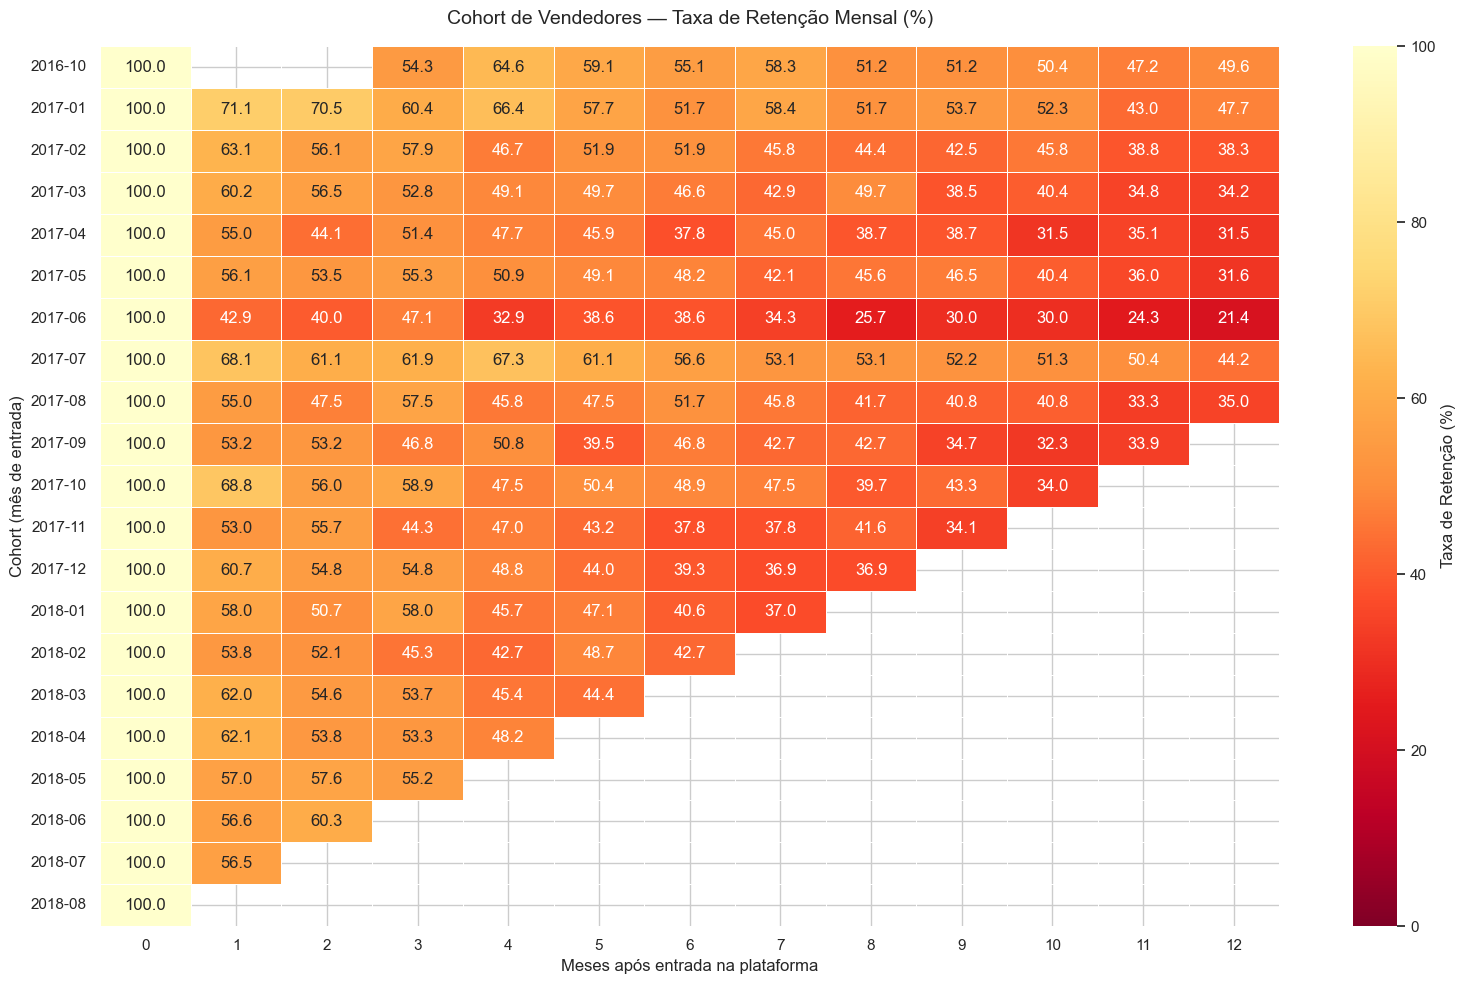

In [11]:
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    retention,
    mask=retention.isnull(),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd_r",
    linewidths=0.5,
    linecolor="white",
    vmin=0, vmax=100,
    cbar_kws={"label": "Taxa de Retenção (%)"},
    ax=ax
)

ax.set_title("Cohort de Vendedores — Taxa de Retenção Mensal (%)", fontsize=14, pad=16)
ax.set_xlabel("Meses após entrada na plataforma")
ax.set_ylabel("Cohort (mês de entrada)")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../reports/02_cohort_vendedores.png", dpi=150)
plt.show()

### Curva média de retenção

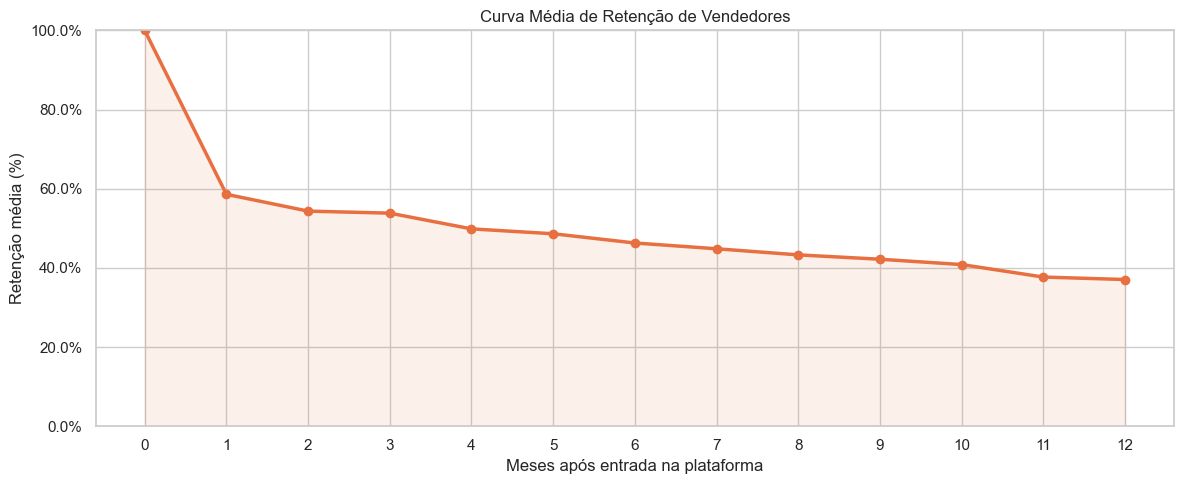

Retenção no mês 1: 58.6%
Retenção no mês 3: 53.8%
Retenção no mês 6: 46.3%


In [12]:
retencao_media = retention.mean(axis=0).reset_index()
retencao_media.columns = ["periodo", "retencao_media"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    retencao_media["periodo"],
    retencao_media["retencao_media"],
    color="#E87040", linewidth=2.5, marker="o", markersize=6
)
ax.fill_between(
    retencao_media["periodo"],
    retencao_media["retencao_media"],
    alpha=0.1, color="#E87040"
)

ax.set_xticks(retencao_media["periodo"])
ax.set_xlabel("Meses após entrada na plataforma")
ax.set_ylabel("Retenção média (%)")
ax.set_title("Curva Média de Retenção de Vendedores")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("../reports/02_curva_retencao_vendedores.png", dpi=150)
plt.show()

for mes in [1, 3, 6]:
    if mes in retencao_media["periodo"].values:
        val = retencao_media.loc[retencao_media["periodo"] == mes, "retencao_media"].values[0]
        print(f"Retenção no mês {mes}: {val:.1f}%")

### Receita por tempo de vida do vendedor

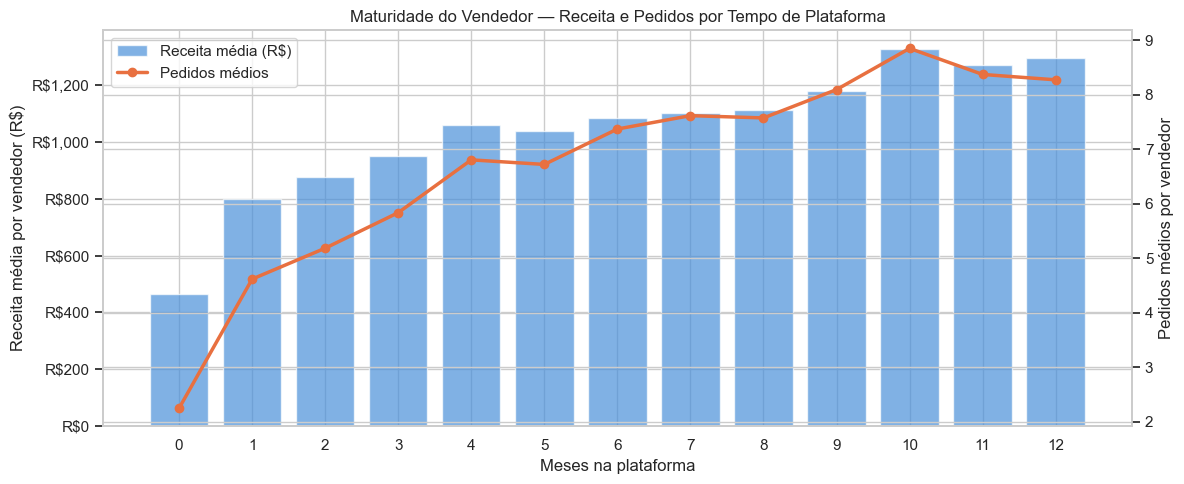

In [13]:
receita_periodo = (
    df.groupby("periodo")
    .agg(
        receita_media=("receita", "mean"),
        pedidos_medio=("pedidos", "mean"),
        vendedores=("seller_id", "nunique")
    )
    .reset_index()
    .query("periodo <= 12")
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(receita_periodo["periodo"], receita_periodo["receita_media"],
        color="#4A90D9", alpha=0.7, label="Receita média (R$)")
ax2.plot(receita_periodo["periodo"], receita_periodo["pedidos_medio"],
         color="#E87040", linewidth=2.5, marker="o", label="Pedidos médios")

ax1.set_xticks(receita_periodo["periodo"])
ax1.set_xlabel("Meses na plataforma")
ax1.set_ylabel("Receita média por vendedor (R$)")
ax2.set_ylabel("Pedidos médios por vendedor")
ax1.set_title("Maturidade do Vendedor — Receita e Pedidos por Tempo de Plataforma")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("../reports/02_maturidade_vendedor.png", dpi=150)
plt.show()

## 💡 Insights acionáveis

1. **Queda crítica no mês 1**: grande parte dos vendedores abandona a
   plataforma no primeiro mês → programa de onboarding estruturado
   nos primeiros 30 dias é alavanca prioritária

2. **Vendedores maduros geram mais receita**: receita e pedidos crescem
   com o tempo de plataforma → reter vendedores existentes é mais
   eficiente do que adquirir novos

3. **Limitação identificada**: `customer_id` do Olist não permite análise
   de recompra de consumidores → em produção, usar ID de conta autenticada
   ou cookie persistente resolve esse problema

### Fecha conexão

In [14]:
conn.close()
print("✅ Notebook 02 concluído — gráficos salvos em reports/")

✅ Notebook 02 concluído — gráficos salvos em reports/
